In [5]:
import sys
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "utils"))


# avec markdown intégré sans images et avec balise
from chunking.factory import ExtractConfig, UniversalExtractorFactory
from chunking.factory import make_ollama_image_summarizer, make_ollama_text_summarizer

# 1. Extraction pdf, words & ppt

In [13]:
from pathlib import Path

cfg = ExtractConfig(artifacts_path="/Users/foulhad/.cache/docling/models")

image_summarizer = make_ollama_image_summarizer("qwen2.5vl:3b")
text_summarizer = make_ollama_text_summarizer("llama3.2:3b")

docx_path = (PROJECT_ROOT / "pdfs/template_lightOn.pdf").resolve()
print(docx_path, docx_path.exists())

factory = UniversalExtractorFactory(config=ExtractConfig(), image_summarizer=image_summarizer, text_summarizer=text_summarizer)
res = factory.extract(str(docx_path))  #workshops_echantillonnage.pptx") #template_lightOn.docx")    #"240504434v5.pdf")

# res.artifacts['markdown_base']
# res.artifacts['markdown_final']
# res.artifacts['tables']

md_desc = res.artifacts["markdown_descriptions_only"]
print(md_desc[:1000])

2026-01-16 16:25:25,990 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]


/Users/foulhad/repos/ministere_interieur/pdfs/template_lightOn.pdf True


2026-01-16 16:25:26,616 - INFO - Going to convert document batch...
2026-01-16 16:25:26,617 - INFO - Initializing pipeline for StandardPdfPipeline with options hash 633cea025f8cb53d9b41789a87a9bfa5
2026-01-16 16:25:26,805 - INFO - Loading plugin 'docling_defaults'
2026-01-16 16:25:26,814 - INFO - Registered picture descriptions: ['vlm', 'api']
2026-01-16 16:25:26,839 - INFO - Loading plugin 'docling_defaults'
2026-01-16 16:25:26,884 - INFO - Registered ocr engines: ['auto', 'easyocr', 'ocrmac', 'rapidocr', 'tesserocr', 'tesseract']
2026-01-16 16:25:33,429 - INFO - Auto OCR model selected ocrmac.
2026-01-16 16:25:33,435 - INFO - Loading plugin 'docling_defaults'
2026-01-16 16:25:33,492 - INFO - Registered layout engines: ['docling_layout_default', 'docling_experimental_table_crops_layout']
2026-01-16 16:25:33,589 - INFO - Accelerator device: 'mps'
2026-01-16 16:25:34,455 - INFO - Loading plugin 'docling_defaults'
2026-01-16 16:25:34,463 - INFO - Registered table structure engines: ['doc

## Descriptifs des images

<!-- image:#/pictures/9 -->
> **Descriptif image (#/pictures/9)** : Cette image présente un tableau qui décrit les différentes couleurs de TLP (Type de Lien de Protection) utilisées dans un système RAG. Les couleurs sont TLP:RED, TLP:AMBER, TLP:GREEN et TLP:WHITE. TLP:RED est utilisé lorsque les informations pourraient avoir des impacts sur le respect d'une réglementation, de la stratégie, de la réputation ou des opérations d'un

<!-- image:#/pictures/18 -->
> **Descriptif image (#/pictures/18)** : L'image montre un texte en français qui se lit comme suit : "nous simplifions le complexe." Le texte est écrit en blanc sur un fond noir, avec une silhouette d'une personne en haut à droite. Le texte est clairement visible et bien legible.

<!-- image:#/pictures/32 -->
> **Descriptif image (#/pictures/32)** : Cette image illustre différentes approches pour générer des réponses en utilisant des modèles de langage pré-entraînés (LLM). Elle compare trois méthodes : le

In [10]:
res.artifacts['markdown_final'][:10000]

'\n\n## DeepSeek-V2: A Strong, Economical, and Efficient Mixture-of-Experts Language Model\n\nDeepSeek-AI\n\nresearch@deepseek.com\n\n## Abstract\n\nWe present DeepSeek-V2, a strong Mixture-of-Experts (MoE) language model characterized by economical training and efficient inference. It comprises 236B total parameters, of which 21B are activated for each token, and supports a context length of 128K tokens. DeepSeek-V2 adopts innovative architectures including Multi-head Latent Attention (MLA) and DeepSeekMoE. MLAguarantees efficient inference through significantly compressing the Key-Value (KV) cache into a latent vector, while DeepSeekMoE enables training strong models at an economical cost through sparse computation. Compared with DeepSeek 67B, DeepSeek-V2 achieves significantly stronger performance, and meanwhile saves 42.5% of training costs, reduces the KV cache by 93.3%, and boosts the maximum generation throughput to 5.76 times. We pretrain DeepSeek-V2 on a high-quality and multi

In [49]:
#res.display_markdown(key="markdown_final")


# 2. Chunks pdf, word & ppt

à rajouter :
- si j'ai un tableau pour tables des matières dans un chunks je l'enlève
- si j'ai un taleau qui est grand sans résumer du tableau je l'enlève

## 2.1 Chunks words & pdf

In [ ]:
from __future__ import annotations

import re
import logging
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# =========================
# Configuration
# =========================
@dataclass
class ChunkingConfig:
    chunk_size_tokens: int = 1000
    chunk_overlap_tokens: int = 100
    chars_per_token: int = 4

    drop_bibliography: bool = True
    drop_appendix: bool = True
    stop_after_appendix_start: bool = True 
    
    min_chunk_chars: int = 200
    remove_docling_placeholders: bool = True

    # appendix_markers: Tuple[str, ...] = ("appendix", "appendices", "annexe", "annexes", "appendice")
    # bibliography_markers: Tuple[str, ...] = ("references", "bibliography", "références", "bibliographie")
    appendix_markers: Tuple[str, ...] = ("annexe", "annexes", "appendix", "appendice", "conclusion")
    bibliography_markers: Tuple[str, ...] = ("bibliographie", "references", "sources")
    conclusion_markers: Tuple[str, ...] = ("conclusion",)
    stop_after_conclusion: bool = True

    allow_numbered_headings: bool = True
    allow_named_headings: bool = True

# =========================
# Tokenizer
# =========================
def _get_tokenizer():
    try:
        import tiktoken
        return tiktoken.get_encoding("cl100k_base")
    except: return None

_TOKENIZER = _get_tokenizer()

def _count_tokens(text: str, cfg: ChunkingConfig) -> int:
    if _TOKENIZER: return len(_TOKENIZER.encode(text))
    return len(text) // cfg.chars_per_token

# =========================
# Détection Appendices (Règle des 2 mots)
# =========================
def _is_marker_present(title: str, markers: Tuple[str, ...]) -> bool:
    t = title.lower().strip()
    t_clean = re.sub(r'^[\d\.]+\s+', '', t)
    for m in markers:
        pattern = rf"\b{re.escape(m)}\b"
        if re.search(pattern, t_clean):
            # exception : "conclusion" peut avoir un titre long
            if m == "conclusion":
                return True

            words = t_clean.split()
            if len(words) <= 2: 
                return True
    return False

# =========================
# Helpers Structure (Extraction par blocs)
# =========================
_TABLE_RE = re.compile(r'((?:\n|^)\|.*\|(?:\n\|.*\|)+)', re.MULTILINE)

def _extract_blocks(text: str) -> List[Dict[str, Any]]:
    """Sépare une section en blocs (paragraphes/tables) avec leurs offsets."""
    blocks = []
    last_idx = 0
    for match in _TABLE_RE.finditer(text):
        prev_text = text[last_idx:match.start()].strip()
        if prev_text:
            for p in re.split(r'\n{2,}', prev_text):
                p_clean = p.strip()
                if p_clean:
                    # On trouve la position réelle du paragraphe dans la section
                    blocks.append({
                        "type": "paragraph", 
                        "content": p_clean, 
                        "offset": text.find(p_clean, last_idx)
                    })
        
        table_title = "Tableau sans titre"
        if blocks and blocks[-1]["type"] == "paragraph":
            lines = blocks[-1]["content"].split('\n')
            if re.search(r'^(Tableau|Table|Tab\.)\s*[:\d]', lines[-1].strip(), re.I):
                table_title = lines[-1].strip()
                rem = "\n".join(lines[:-1]).strip()
                if rem: blocks[-1]["content"] = rem
                else: blocks.pop()
        
        blocks.append({
            "type": "table", 
            "content": match.group(0).strip(), 
            "title": table_title, 
            "offset": match.start()
        })
        last_idx = match.end()

    rem = text[last_idx:].strip()
    if rem:
        for p in re.split(r'\n{2,}', rem):
            p_clean = p.strip()
            if p_clean:
                blocks.append({
                    "type": "paragraph", 
                    "content": p_clean, 
                    "offset": text.find(p_clean, last_idx)
                })
    return blocks

def _extract_sections(md: str, cfg: ChunkingConfig) -> List[Dict[str, Any]]:
    """Extrait les sections avec l'index 'start' global."""
    markers = []
    for m in re.finditer(r"^(#{1,6})\s+(.+?)\s*$", md, re.MULTILINE):
        markers.append((m.start(), m.end(), m.group(2).strip(), len(m.group(1))))
    
    if cfg.allow_numbered_headings:
        for m in re.finditer(r"^(?P<num>\d+(?:\.\d+)*)\.\s+(?P<title>[A-ZÀ-Ÿ].{1,120})\s*$", md, re.MULTILINE):
            num = m.group("num")
            markers.append((m.start(), m.end(), f"{num} {m.group('title')}", num.count(".") + 1))
    
    if not markers: return [{"title": "document", "level": 1, "text": md, "start": 0}]
    
    markers.sort(key=lambda x: x[0])
    sections = []
    for i, (start, _, title, level) in enumerate(markers):
        end = markers[i + 1][0] if i + 1 < len(markers) else len(md)
        sections.append({
            "title": title, 
            "level": level, 
            "text": md[start:end].strip(),
            "start": start
        })
    return sections

def _add_section_paths(sections: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    stack = []
    out = []
    for sec in sections:
        lvl = sec["level"]
        while stack and stack[-1][0] >= lvl: stack.pop()
        stack.append((lvl, sec["title"]))
        sec["section_path"] = " > ".join([t for _, t in stack])
        out.append(sec)
    return out

# =========================
# Modèle Chunk & Main
# =========================
@dataclass
class Chunk:
    id: str
    source: str
    section_path: str
    section_title: str
    text: str
    page_no: int
    meta: Dict[str, Any]

def chunk_from_extract_result(res: Any, cfg: Optional[ChunkingConfig] = None) -> List[Chunk]:
    cfg = cfg or ChunkingConfig()
    md = res.artifacts.get("markdown_final") or res.artifacts.get("markdown_base") or ""
    if not isinstance(md, str): md = str(md)
    
    # --- LOGIQUE DE PAGES ---
    # On splitte pour avoir le contenu brut de chaque page (Map Page 1, 2, 3...)
    pages_raw = md.split("<!-- page_break -->")
    # On nettoie les balises pour que le texte de la page soit propre
    page_map = {i+1: p.replace("<!-- page_break -->", "").strip() for i, p in enumerate(pages_raw)}
    
    all_sections = _add_section_paths(_extract_sections(md, cfg))
    chunks: List[Chunk] = []
    source = getattr(res, "source", "unknown")
    in_excluded_zone = False

    for si, sec in enumerate(all_sections):
        sec_start_pos = sec["start"]
        path = sec["section_path"]
        title = sec["title"]

        # --- Détection Exclusion ---
        is_bib = _is_marker_present(title, cfg.bibliography_markers)
        is_app = _is_marker_present(title, cfg.appendix_markers) or \
                 _is_marker_present(path.split(" > ")[0], cfg.appendix_markers)

        if (is_bib or is_app) and (si / len(all_sections) > 0.4):
            if sec["level"] <= 2: in_excluded_zone = True

        if in_excluded_zone and cfg.stop_after_appendix_start: continue
        if (is_bib and cfg.drop_bibliography) or (is_app and cfg.drop_appendix): continue

        # --- Chunking par blocs ---
        blocks = _extract_blocks(sec["text"])
        current_text_buffer = []
        current_tokens = 0
        
        # On initialise la page de début du chunk courant
        buffer_start_page = 1

        for bi, block in enumerate(blocks):
            # CALCUL DE PAGE ABSOLU (Nombre de sauts de page avant ce bloc + 1)
            absolute_pos = sec_start_pos + block.get("offset", 0)
            block_page = md[:absolute_pos].count("<!-- page_break -->") #+ 1
            
            clean_content = block["content"].replace("<!-- page_break -->", "").strip()

            if block["type"] == "table":
                # Si on a du texte en attente, on le flush avant le tableau
                if current_text_buffer:
                    chunks.append(_build_chunk_with_page(current_text_buffer, si, source, sec, buffer_start_page, cfg, page_map))
                    current_text_buffer, current_tokens = [], 0
                
                table_text = f"SECTION: {path}\nTITRE TABLEAU: {block['title']}\n\n{clean_content}"
                chunks.append(Chunk(
                    id=f"{source}::s{si}::t{bi}",
                    source=source,
                    section_path=path,
                    section_title=title,
                    text=table_text,
                    page_no=block_page,
                    meta={
                        "type": "table", 
                        "full_page_text": page_map.get(block_page, "") # <--- Référence page complète
                    } 
                ))
            else:
                p_tokens = _count_tokens(clean_content, cfg)
                
                # Si on démarre un nouveau chunk, on mémorise sa page de départ
                if not current_text_buffer:
                    buffer_start_page = block_page

                if current_tokens + p_tokens > cfg.chunk_size_tokens and current_text_buffer:
                    chunks.append(_build_chunk_with_page(current_text_buffer, si, source, sec, buffer_start_page, cfg, page_map))
                    # Overlap : on garde le dernier paragraphe
                    current_text_buffer = [current_text_buffer[-1], clean_content] if len(current_text_buffer) > 1 else [clean_content]
                    current_tokens = _count_tokens("\n\n".join(current_text_buffer), cfg)
                    # Note : buffer_start_page reste celui du paragraphe conservé
                else:
                    current_text_buffer.append(clean_content)
                    current_tokens += p_tokens

        # Flush final pour la section
        if current_text_buffer:
            chunks.append(_build_chunk_with_page(current_text_buffer, si, source, sec, buffer_start_page, cfg, page_map))

    return [c for c in chunks if len(c.text) >= cfg.min_chunk_chars]

def _build_chunk_with_page(buffer: List[str], si: int, source: str, sec: Dict, page_no: int, cfg: ChunkingConfig, page_map: Dict) -> Chunk:
    full_text = "\n\n".join(buffer)
    return Chunk(
        id=f"{source}::s{si}::c{si}_{page_no}",
        source=source,
        section_path=sec["section_path"],
        section_title=sec["title"],
        text=full_text,
        page_no=page_no,
        meta={
            "type": "text", 
            "tokens_est": _count_tokens(full_text, cfg),
            "page_context": f"Contenu extrait de la page {page_no}",
            "full_page_text": page_map.get(page_no, "") # <--- Toute la page est ici
        }
    )

In [ ]:
from __future__ import annotations

import re
import logging
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# =========================
# Configuration
# =========================
@dataclass
class ChunkingConfig:
    chunk_size_tokens: int = 1000
    chunk_overlap_tokens: int = 100  # (not used strictly, kept for compatibility)
    chars_per_token: int = 4

    drop_bibliography: bool = True
    drop_appendix: bool = True
    stop_after_appendix_start: bool = True

    min_chunk_chars: int = 200
    remove_docling_placeholders: bool = True

    # semantic chunking (langchain)
    semantic_breakpoint_threshold_type: str = "percentile"  # 'percentile' | 'standard_deviation' | 'interquartile'
    semantic_embeddings_model: str = "nomic-embed-text"
    semantic_ollama_base_url: str = "http://localhost:11434"
    semantic_scope: str = "section"  # 'section' ou 'page'

    # markers
    appendix_markers: Tuple[str, ...] = ("annexe", "annexes", "appendix", "appendice")
    bibliography_markers: Tuple[str, ...] = ("bibliographie", "references", "sources", "références", "bibliography")
    conclusion_markers: Tuple[str, ...] = ("conclusion",)
    stop_after_conclusion: bool = True

    allow_numbered_headings: bool = True
    allow_named_headings: bool = True


# =========================
# Tokenizer
# =========================
def _get_tokenizer():
    try:
        import tiktoken
        return tiktoken.get_encoding("cl100k_base")
    except Exception:
        return None


_TOKENIZER = _get_tokenizer()


def _count_tokens(text: str, cfg: ChunkingConfig) -> int:
    if _TOKENIZER:
        return len(_TOKENIZER.encode(text))
    return max(1, len(text) // cfg.chars_per_token)


# =========================
# Marker detection
# =========================
def _is_marker_present(title: str, markers: Tuple[str, ...], *, allow_long_title: bool = False) -> bool:
    """
    Detect markers in a heading.
    - default behavior: marker must be present AND heading is short (<=2 words) after removing numbering
    - allow_long_title=True: marker presence is enough (used for Conclusion)
    """
    t = (title or "").lower().strip()
    t_clean = re.sub(r'^[\d\.]+\s*', '', t).strip()

    for m in markers:
        pattern = rf"\b{re.escape(m)}\b"
        if re.search(pattern, t_clean):
            if allow_long_title:
                return True
            words = t_clean.split()
            if len(words) <= 2:
                return True
    return False


def _is_conclusion_heading(title: str, cfg: ChunkingConfig) -> bool:
    # conclusion should match even if the title is long like:
    # "5. Conclusion, Limitation, and Future Work"
    return _is_marker_present(title, cfg.conclusion_markers, allow_long_title=True)


# =========================
# Helpers Structure (Extraction par blocs)
# =========================
_TABLE_RE = re.compile(r'((?:\n|^)\|.*\|(?:\n\|.*\|)+)', re.MULTILINE)


def _extract_blocks(text: str) -> List[Dict[str, Any]]:
    """Sépare une section en blocs (paragraphes/tables) avec leurs offsets (offset relatif à la section)."""
    blocks: List[Dict[str, Any]] = []
    last_idx = 0

    for match in _TABLE_RE.finditer(text):
        prev_text = text[last_idx:match.start()].strip()
        if prev_text:
            for p in re.split(r'\n{2,}', prev_text):
                p_clean = p.strip()
                if p_clean:
                    blocks.append({
                        "type": "paragraph",
                        "content": p_clean,
                        "offset": text.find(p_clean, last_idx),
                    })

        table_title = "Tableau sans titre"
        if blocks and blocks[-1]["type"] == "paragraph":
            lines = blocks[-1]["content"].split('\n')
            if re.search(r'^(Tableau|Table|Tab\.)\s*[:\d]', lines[-1].strip(), re.I):
                table_title = lines[-1].strip()
                rem = "\n".join(lines[:-1]).strip()
                if rem:
                    blocks[-1]["content"] = rem
                else:
                    blocks.pop()

        blocks.append({
            "type": "table",
            "content": match.group(0).strip(),
            "title": table_title,
            "offset": match.start(),
        })
        last_idx = match.end()

    rem = text[last_idx:].strip()
    if rem:
        for p in re.split(r'\n{2,}', rem):
            p_clean = p.strip()
            if p_clean:
                blocks.append({
                    "type": "paragraph",
                    "content": p_clean,
                    "offset": text.find(p_clean, last_idx),
                })

    return blocks


def _extract_sections(md: str, cfg: ChunkingConfig) -> List[Dict[str, Any]]:
    """Extrait les sections avec l'index 'start' global."""
    markers: List[Tuple[int, int, str, int]] = []

    # Markdown headings
    for m in re.finditer(r"^(#{1,6})\s+(.+?)\s*$", md, re.MULTILINE):
        markers.append((m.start(), m.end(), m.group(2).strip(), len(m.group(1))))

    # Numbered headings like "4.1. Title"
    if cfg.allow_numbered_headings:
        for m in re.finditer(
            r"^(?P<num>\d+(?:\.\d+)*)\.\s+(?P<title>[A-ZÀ-Ÿ].{1,120})\s*$",
            md,
            re.MULTILINE,
        ):
            num = m.group("num")
            markers.append((m.start(), m.end(), f"{num} {m.group('title')}", num.count(".") + 1))

    if not markers:
        return [{"title": "document", "level": 1, "text": md, "start": 0}]

    markers.sort(key=lambda x: x[0])

    sections: List[Dict[str, Any]] = []
    for i, (start, _, title, level) in enumerate(markers):
        end = markers[i + 1][0] if i + 1 < len(markers) else len(md)
        sections.append({
            "title": title,
            "level": level,
            "text": md[start:end].strip(),
            "start": start,
        })
    return sections


def _add_section_paths(sections: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    stack: List[Tuple[int, str]] = []
    out: List[Dict[str, Any]] = []
    for sec in sections:
        lvl = sec["level"]
        while stack and stack[-1][0] >= lvl:
            stack.pop()
        stack.append((lvl, sec["title"]))
        sec["section_path"] = " > ".join([t for _, t in stack])
        out.append(sec)
    return out


# =========================
# Chunk Model
# =========================
@dataclass
class Chunk:
    id: str
    source: str
    section_path: str
    section_title: str
    text: str
    page_no: int
    meta: Dict[str, Any]


def _make_semantic_splitter(cfg: ChunkingConfig):
    # pip install langchain-experimental langchain-community
    from langchain_experimental.text_splitter import SemanticChunker
    try:
        from langchain_community.embeddings import OllamaEmbeddings
        emb = OllamaEmbeddings(model=cfg.semantic_embeddings_model, base_url=cfg.semantic_ollama_base_url)
    except Exception:
        # fallback ultra robuste si ta version n'a pas OllamaEmbeddings
        import requests
        from langchain_core.embeddings import Embeddings

        class _OllamaEmbeddingsWrapper(Embeddings):
            def __init__(self, model: str, base_url: str):
                self.model = model
                self.base_url = base_url.rstrip("/")

            def embed_documents(self, texts: List[str]) -> List[List[float]]:
                return [self._embed(t) for t in texts]

            def embed_query(self, text: str) -> List[float]:
                return self._embed(text)

            def _embed(self, text: str) -> List[float]:
                r = requests.post(
                    f"{self.base_url}/api/embeddings",
                    json={"model": self.model, "prompt": text},
                    timeout=120,
                )
                r.raise_for_status()
                return r.json()["embedding"]

        emb = _OllamaEmbeddingsWrapper(cfg.semantic_embeddings_model, cfg.semantic_ollama_base_url)

    return SemanticChunker(
        emb,
        breakpoint_threshold_type=cfg.semantic_breakpoint_threshold_type,
    )


# =========================
# Main
# =========================
def semantic_chunk_from_extract_result(res: Any, cfg: Optional[ChunkingConfig] = None) -> List[Chunk]:
    cfg = cfg or ChunkingConfig()
    md = res.artifacts.get("markdown_final") or res.artifacts.get("markdown_base") or ""
    if not isinstance(md, str):
        md = str(md)

    source = getattr(res, "source", "unknown")

    # pages
    pages_raw = md.split("<!-- page_break -->")
    page_map = {i + 1: p.replace("<!-- page_break -->", "").strip() for i, p in enumerate(pages_raw)}

    # sections (pour garder section_path / section_title)
    all_sections = _add_section_paths(_extract_sections(md, cfg))

    # cutoff après conclusion (même logique que structurel)
    conclusion_idx = None
    for i, s in enumerate(all_sections):
        if _is_conclusion_heading(s["title"], cfg):
            conclusion_idx = i
            break

    conclusion_cutoff_pos = None
    if conclusion_idx is not None and cfg.stop_after_conclusion:
        conclusion_cutoff_pos = all_sections[conclusion_idx + 1]["start"] if (conclusion_idx + 1) < len(all_sections) else len(md)

    splitter = _make_semantic_splitter(cfg)

    chunks: List[Chunk] = []

    if cfg.semantic_scope == "page":
        # semantic par page = stable et rapide (texte plus petit)
        for page_no, page_text in page_map.items():
            t = (page_text or "").strip()
            if len(t) < cfg.min_chunk_chars:
                continue

            sem_texts = [d.page_content for d in splitter.create_documents([t])]

            for ci, chunk_text in enumerate(sem_texts):
                chunk_text = (chunk_text or "").strip()
                if len(chunk_text) < cfg.min_chunk_chars:
                    continue

                chunks.append(Chunk(
                    id=f"{source}::p{page_no}::sem{ci}",
                    source=source,
                    section_path="document",
                    section_title="document",
                    text=chunk_text,
                    page_no=int(page_no),
                    meta={
                        "type": "text",
                        "chunking": "semantic",
                        "scope": "page",
                        "tokens_est": _count_tokens(chunk_text, cfg),
                        "page_context": f"Contenu extrait (semantic) de la page {page_no}",
                        "full_page_text": page_map.get(page_no, ""),
                    }
                ))

        return chunks

    # semantic par section = meilleure sémantique, mais peut être plus lourd
    for si, sec in enumerate(all_sections):
        sec_start_pos = sec["start"]
        if conclusion_cutoff_pos is not None and sec_start_pos >= conclusion_cutoff_pos:
            break

        path = sec["section_path"]
        title = sec["title"]

        # exclusions biblio/annexe (même logique)
        is_bib = _is_marker_present(title, cfg.bibliography_markers)
        is_app = _is_marker_present(title, cfg.appendix_markers) or _is_marker_present(path.split(" > ")[0], cfg.appendix_markers)
        if (is_bib and cfg.drop_bibliography) or (is_app and cfg.drop_appendix):
            continue

        sec_text = (sec["text"] or "").replace("<!-- page_break -->", "").strip()
        if len(sec_text) < cfg.min_chunk_chars:
            continue

        # page_no approx (début de section)
        page_no = md[:sec_start_pos].count("<!-- page_break -->") + 1

        sem_texts = [d.page_content for d in splitter.create_documents([sec_text])]

        for ci, chunk_text in enumerate(sem_texts):
            chunk_text = (chunk_text or "").strip()
            if len(chunk_text) < cfg.min_chunk_chars:
                continue

            chunks.append(Chunk(
                id=f"{source}::s{si}::sem{ci}",
                source=source,
                section_path=path,
                section_title=title,
                text=chunk_text,
                page_no=int(page_no),
                meta={
                    "type": "text",
                    "chunking": "semantic",
                    "scope": "section",
                    "abs_pos": int(sec_start_pos),
                    "tokens_est": _count_tokens(chunk_text, cfg),
                    "page_context": f"Contenu extrait (semantic) autour de la page {page_no}",
                    "full_page_text": page_map.get(page_no, ""),
                }
            ))

    # filter hard cutoff (défensif)
    if conclusion_cutoff_pos is not None:
        chunks = [c for c in chunks if int(c.meta.get("abs_pos", 0)) < conclusion_cutoff_pos]

    return chunks


def chunk_from_extract_result(res: Any, cfg: Optional[ChunkingConfig] = None) -> List[Chunk]:
    cfg = cfg or ChunkingConfig()
    md = res.artifacts.get("markdown_final") or res.artifacts.get("markdown_base") or ""
    if not isinstance(md, str):
        md = str(md)

    # --- LOGIQUE DE PAGES ---
    pages_raw = md.split("<!-- page_break -->")
    page_map = {i + 1: p.replace("<!-- page_break -->", "").strip() for i, p in enumerate(pages_raw)}

    all_sections = _add_section_paths(_extract_sections(md, cfg))
    chunks: List[Chunk] = []
    source = getattr(res, "source", "unknown")

    # --- cutoff global après Conclusion ---
    conclusion_idx = None
    for i, s in enumerate(all_sections):
        if _is_conclusion_heading(s["title"], cfg):
            conclusion_idx = i
            break

    conclusion_cutoff_pos = None
    if conclusion_idx is not None and cfg.stop_after_conclusion:
        conclusion_cutoff_pos = all_sections[conclusion_idx + 1]["start"] if (conclusion_idx + 1) < len(all_sections) else len(md)

    in_excluded_zone = False

    for si, sec in enumerate(all_sections):
        sec_start_pos = sec["start"]
        path = sec["section_path"]
        title = sec["title"]

        # Stop global après la section Conclusion
        if conclusion_cutoff_pos is not None and sec_start_pos >= conclusion_cutoff_pos:
            break

        # --- Détection Exclusion (bibliography/appendix) ---
        is_bib = _is_marker_present(title, cfg.bibliography_markers)
        is_app = _is_marker_present(title, cfg.appendix_markers) or _is_marker_present(path.split(" > ")[0], cfg.appendix_markers)

        if (is_bib or is_app) and (si / max(1, len(all_sections)) > 0.4):
            if sec["level"] <= 2:
                in_excluded_zone = True

        if in_excluded_zone and cfg.stop_after_appendix_start:
            # "stop" (not just skip) once appendix/biblio zone begins
            break

        if (is_bib and cfg.drop_bibliography) or (is_app and cfg.drop_appendix):
            continue

        # --- Chunking par blocs ---
        blocks = _extract_blocks(sec["text"])

        # buffer stores tuples: (content, abs_pos, page_no)
        buffer: List[Tuple[str, int, int]] = []
        buffer_tokens = 0

        for bi, block in enumerate(blocks):
            rel_off = int(block.get("offset", 0) or 0)
            absolute_pos = sec_start_pos + rel_off

            # page number (1-indexed)
            block_page = md[:absolute_pos].count("<!-- page_break -->") + 1

            clean_content = (block["content"] or "").replace("<!-- page_break -->", "").strip()
            if not clean_content:
                continue

            # If we're past conclusion cutoff (very defensive)
            if conclusion_cutoff_pos is not None and absolute_pos >= conclusion_cutoff_pos:
                break

            if block["type"] == "table":
                # flush buffer before table
                if buffer:
                    chunks.append(_build_chunk_with_page(buffer, si, bi, source, sec, cfg, page_map))
                    buffer, buffer_tokens = [], 0

                table_text = f"SECTION: {path}\nTITRE TABLEAU: {block.get('title','Tableau sans titre')}\n\n{clean_content}"
                chunks.append(Chunk(
                    id=f"{source}::s{si}::t{bi}",
                    source=source,
                    section_path=path,
                    section_title=title,
                    text=table_text,
                    page_no=block_page,
                    meta={
                        "type": "table",
                        "abs_pos": absolute_pos,
                        "page_context": f"Contenu extrait de la page {block_page}",
                        "full_page_text": page_map.get(block_page, ""),
                    }
                ))
                continue

            # paragraph
            p_tokens = _count_tokens(clean_content, cfg)

            if not buffer:
                buffer = [(clean_content, absolute_pos, block_page)]
                buffer_tokens = p_tokens
                continue

            if buffer_tokens + p_tokens > cfg.chunk_size_tokens:
                # flush current buffer
                chunks.append(_build_chunk_with_page(buffer, si, bi, source, sec, cfg, page_map))

                # overlap: keep last paragraph only
                last = buffer[-1]
                buffer = [last, (clean_content, absolute_pos, block_page)]
                buffer_tokens = _count_tokens("\n\n".join([x[0] for x in buffer]), cfg)
            else:
                buffer.append((clean_content, absolute_pos, block_page))
                buffer_tokens += p_tokens

        # flush remaining buffer
        if buffer:
            chunks.append(_build_chunk_with_page(buffer, si, len(blocks), source, sec, cfg, page_map))

    # Final filtering
    out = [c for c in chunks if len(c.text) >= cfg.min_chunk_chars]

    # Hard filter after conclusion cutoff, if any
    if conclusion_cutoff_pos is not None:
        out = [c for c in out if int(c.meta.get("abs_pos", 0)) < conclusion_cutoff_pos]



    return out

def chunk_dispatch(res: Any, *, cfg: Optional[ChunkingConfig] = None, strategy: str = "structure") -> List[Chunk]:
    if strategy == "structure":
        return chunk_from_extract_result(res, cfg=cfg)
    if strategy == "semantic":
        return semantic_chunk_from_extract_result(res, cfg=cfg)
    raise ValueError("strategy must be 'structure' or 'semantic'")



def _build_chunk_with_page(
    buffer: List[Tuple[str, int, int]],
    si: int,
    bi: int,
    source: str,
    sec: Dict[str, Any],
    cfg: ChunkingConfig,
    page_map: Dict[int, str],
) -> Chunk:
    texts = [x[0] for x in buffer]
    abs_pos = int(buffer[0][1]) if buffer else int(sec.get("start", 0))
    page_no = int(buffer[0][2]) if buffer else 1

    full_text = "\n\n".join(texts)

    return Chunk(
        id=f"{source}::s{si}::c{si}_{page_no}_{bi}",
        source=source,
        section_path=sec["section_path"],
        section_title=sec["title"],
        text=full_text,
        page_no=page_no,
        meta={
            "type": "text",
            "abs_pos": abs_pos,
            "tokens_est": _count_tokens(full_text, cfg),
            "page_context": f"Contenu extrait de la page {page_no}",
            "full_page_text": page_map.get(page_no, ""),
        },
    )


In [14]:
config = ChunkingConfig(
    chunk_size_tokens=1000,
    chunk_overlap_tokens=100,
    drop_bibliography=True,         # Filtre la biblio
    drop_appendix=True,             # Filtre les annexes
    stop_after_appendix_start=True  # Arrête le script si une annexe est détectée
)

# Appel de votre fonction
chunks = chunk_from_extract_result(res, cfg=config)

In [14]:
from __future__ import annotations

import re
import logging
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# =========================
# Configuration
# =========================
@dataclass
class ChunkingConfig:
    chunk_size_tokens: int = 1000
    chunk_overlap_tokens: int = 100  # (not used strictly, kept for compatibility)
    chars_per_token: int = 4

    drop_bibliography: bool = True
    drop_appendix: bool = True
    stop_after_appendix_start: bool = True

    min_chunk_chars: int = 200
    remove_docling_placeholders: bool = True

    # semantic chunking (langchain)
    semantic_breakpoint_threshold_type: str = "percentile"  # 'percentile' | 'standard_deviation' | 'interquartile'
    semantic_embeddings_model: str = "nomic-embed-text"
    semantic_ollama_base_url: str = "http://localhost:11434"
    semantic_scope: str = "section"  # 'section' ou 'page'

    # markers
    appendix_markers: Tuple[str, ...] = ("annexe", "annexes", "appendix", "appendice")
    bibliography_markers: Tuple[str, ...] = ("bibliographie", "references", "sources", "références", "bibliography")
    conclusion_markers: Tuple[str, ...] = ("conclusion",)
    stop_after_conclusion: bool = True

    allow_numbered_headings: bool = True
    allow_named_headings: bool = True


# =========================
# Tokenizer
# =========================
def _get_tokenizer():
    try:
        import tiktoken
        return tiktoken.get_encoding("cl100k_base")
    except Exception:
        return None


_TOKENIZER = _get_tokenizer()


def _count_tokens(text: str, cfg: ChunkingConfig) -> int:
    if _TOKENIZER:
        return len(_TOKENIZER.encode(text))
    return max(1, len(text) // cfg.chars_per_token)


# =========================
# Marker detection
# =========================
def _is_marker_present(title: str, markers: Tuple[str, ...], *, allow_long_title: bool = False) -> bool:
    """
    Detect markers in a heading.
    - default behavior: marker must be present AND heading is short (<=2 words) after removing numbering
    - allow_long_title=True: marker presence is enough (used for Conclusion)
    """
    t = (title or "").lower().strip()
    t_clean = re.sub(r"^[\d\.]+\s*", "", t).strip()

    for m in markers:
        pattern = rf"\b{re.escape(m)}\b"
        if re.search(pattern, t_clean):
            if allow_long_title:
                return True
            words = t_clean.split()
            if len(words) <= 2:
                return True
    return False


def _is_conclusion_heading(title: str, cfg: ChunkingConfig) -> bool:
    # conclusion should match even if the title is long like:
    # "5. Conclusion, Limitation, and Future Work"
    return _is_marker_present(title, cfg.conclusion_markers, allow_long_title=True)


# =========================
# Helpers Structure (Extraction par blocs)
# =========================
_TABLE_RE = re.compile(r"((?:\n|^)\|.*\|(?:\n\|.*\|)+)", re.MULTILINE)


def _extract_blocks(text: str) -> List[Dict[str, Any]]:
    """Sépare une section en blocs (paragraphes/tables) avec leurs offsets (offset relatif à la section)."""
    blocks: List[Dict[str, Any]] = []
    last_idx = 0

    for match in _TABLE_RE.finditer(text):
        prev_text = text[last_idx:match.start()].strip()
        if prev_text:
            for p in re.split(r"\n{2,}", prev_text):
                p_clean = p.strip()
                if p_clean:
                    blocks.append({
                        "type": "paragraph",
                        "content": p_clean,
                        "offset": text.find(p_clean, last_idx),
                    })

        table_title = "Tableau sans titre"
        if blocks and blocks[-1]["type"] == "paragraph":
            lines = blocks[-1]["content"].split("\n")
            if re.search(r"^(Tableau|Table|Tab\.)\s*[:\d]", lines[-1].strip(), re.I):
                table_title = lines[-1].strip()
                rem = "\n".join(lines[:-1]).strip()
                if rem:
                    blocks[-1]["content"] = rem
                else:
                    blocks.pop()

        blocks.append({
            "type": "table",
            "content": match.group(0).strip(),
            "title": table_title,
            "offset": match.start(),
        })
        last_idx = match.end()

    rem = text[last_idx:].strip()
    if rem:
        for p in re.split(r"\n{2,}", rem):
            p_clean = p.strip()
            if p_clean:
                blocks.append({
                    "type": "paragraph",
                    "content": p_clean,
                    "offset": text.find(p_clean, last_idx),
                })

    return blocks


def _extract_sections(md: str, cfg: ChunkingConfig) -> List[Dict[str, Any]]:
    """Extrait les sections avec l'index 'start' global."""
    markers: List[Tuple[int, int, str, int]] = []

    # Markdown headings
    for m in re.finditer(r"^(#{1,6})\s+(.+?)\s*$", md, re.MULTILINE):
        markers.append((m.start(), m.end(), m.group(2).strip(), len(m.group(1))))

    # Numbered headings like "4.1. Title"
    if cfg.allow_numbered_headings:
        for m in re.finditer(
            r"^(?P<num>\d+(?:\.\d+)*)\.\s+(?P<title>[A-ZÀ-Ÿ].{1,120})\s*$",
            md,
            re.MULTILINE,
        ):
            num = m.group("num")
            markers.append((m.start(), m.end(), f"{num} {m.group('title')}", num.count(".") + 1))

    if not markers:
        return [{"title": "document", "level": 1, "text": md, "start": 0}]

    markers.sort(key=lambda x: x[0])

    sections: List[Dict[str, Any]] = []
    for i, (start, _, title, level) in enumerate(markers):
        end = markers[i + 1][0] if i + 1 < len(markers) else len(md)
        sections.append({
            "title": title,
            "level": level,
            "text": md[start:end].strip(),
            "start": start,
        })
    return sections


def _add_section_paths(sections: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    stack: List[Tuple[int, str]] = []
    out: List[Dict[str, Any]] = []
    for sec in sections:
        lvl = sec["level"]
        while stack and stack[-1][0] >= lvl:
            stack.pop()
        stack.append((lvl, sec["title"]))
        sec["section_path"] = " > ".join([t for _, t in stack])
        out.append(sec)
    return out


# =========================
# Chunk Model
# =========================
@dataclass
class Chunk:
    id: str
    source: str
    section_path: str
    section_title: str
    text: str
    page_no: int
    meta: Dict[str, Any]


# =========================
# Semantic splitter (LangChain)
# =========================
def _make_semantic_splitter(cfg: ChunkingConfig):
    # pip install langchain-experimental langchain-community
    from langchain_experimental.text_splitter import SemanticChunker
    try:
        from langchain_community.embeddings import OllamaEmbeddings
        emb = OllamaEmbeddings(model=cfg.semantic_embeddings_model, base_url=cfg.semantic_ollama_base_url)
    except Exception:
        # fallback ultra robuste si ta version n'a pas OllamaEmbeddings
        import requests
        from langchain_core.embeddings import Embeddings

        class _OllamaEmbeddingsWrapper(Embeddings):
            def __init__(self, model: str, base_url: str):
                self.model = model
                self.base_url = base_url.rstrip("/")

            def embed_documents(self, texts: List[str]) -> List[List[float]]:
                return [self._embed(t) for t in texts]

            def embed_query(self, text: str) -> List[float]:
                return self._embed(text)

            def _embed(self, text: str) -> List[float]:
                r = requests.post(
                    f"{self.base_url}/api/embeddings",
                    json={"model": self.model, "prompt": text},
                    timeout=120,
                )
                r.raise_for_status()
                return r.json()["embedding"]

        emb = _OllamaEmbeddingsWrapper(cfg.semantic_embeddings_model, cfg.semantic_ollama_base_url)

    return SemanticChunker(
        emb,
        breakpoint_threshold_type=cfg.semantic_breakpoint_threshold_type,
    )


# =========================
# Chunking: Semantic
# =========================
def semantic_chunk_from_extract_result(res: Any, cfg: Optional[ChunkingConfig] = None) -> List[Chunk]:
    cfg = cfg or ChunkingConfig()
    md = res.artifacts.get("markdown_final") or res.artifacts.get("markdown_base") or ""
    if not isinstance(md, str):
        md = str(md)

    source = getattr(res, "source", "unknown")

    # pages
    pages_raw = md.split("<!-- page_break -->")
    page_map = {i + 1: p.replace("<!-- page_break -->", "").strip() for i, p in enumerate(pages_raw)}

    # sections (pour garder section_path / section_title)
    all_sections = _add_section_paths(_extract_sections(md, cfg))

    # cutoff après conclusion
    conclusion_idx = None
    for i, s in enumerate(all_sections):
        if _is_conclusion_heading(s["title"], cfg):
            conclusion_idx = i
            break

    conclusion_cutoff_pos = None
    if conclusion_idx is not None and cfg.stop_after_conclusion:
        conclusion_cutoff_pos = all_sections[conclusion_idx + 1]["start"] if (conclusion_idx + 1) < len(all_sections) else len(md)

    splitter = _make_semantic_splitter(cfg)
    chunks: List[Chunk] = []

    if cfg.semantic_scope == "page":
        # semantic par page (souvent le meilleur défaut en perf/stabilité)
        for page_no, page_text in page_map.items():
            t = (page_text or "").strip()
            if len(t) < cfg.min_chunk_chars:
                continue

            sem_texts = [d.page_content for d in splitter.create_documents([t])]

            for ci, chunk_text in enumerate(sem_texts):
                chunk_text = (chunk_text or "").strip()
                if len(chunk_text) < cfg.min_chunk_chars:
                    continue

                chunks.append(Chunk(
                    id=f"{source}::p{page_no}::sem{ci}",
                    source=source,
                    section_path="document",
                    section_title="document",
                    text=chunk_text,
                    page_no=int(page_no),
                    meta={
                        "type": "text",
                        "chunking": "semantic",
                        "scope": "page",
                        "embeddings_model": cfg.semantic_embeddings_model,
                        "breakpoint_threshold_type": cfg.semantic_breakpoint_threshold_type,
                        "tokens_est": _count_tokens(chunk_text, cfg),
                        "page_context": f"Contenu extrait (semantic) de la page {page_no}",
                        "full_page_text": page_map.get(page_no, ""),
                    }
                ))

        return chunks

    # semantic par section
    in_excluded_zone = False

    for si, sec in enumerate(all_sections):
        sec_start_pos = sec["start"]
        if conclusion_cutoff_pos is not None and sec_start_pos >= conclusion_cutoff_pos:
            break

        path = sec["section_path"]
        title = sec["title"]

        # exclusions biblio/annexe + stop_after_appendix_start (même logique que structure)
        is_bib = _is_marker_present(title, cfg.bibliography_markers)
        is_app = _is_marker_present(title, cfg.appendix_markers) or _is_marker_present(path.split(" > ")[0], cfg.appendix_markers)

        if (is_bib or is_app) and (si / max(1, len(all_sections)) > 0.4):
            if sec["level"] <= 2:
                in_excluded_zone = True

        if in_excluded_zone and cfg.stop_after_appendix_start:
            break

        if (is_bib and cfg.drop_bibliography) or (is_app and cfg.drop_appendix):
            continue

        sec_text = (sec["text"] or "").replace("<!-- page_break -->", "").strip()
        if len(sec_text) < cfg.min_chunk_chars:
            continue

        # page_no approx (début de section)
        page_no = md[:sec_start_pos].count("<!-- page_break -->") + 1

        sem_texts = [d.page_content for d in splitter.create_documents([sec_text])]

        for ci, chunk_text in enumerate(sem_texts):
            chunk_text = (chunk_text or "").strip()
            if len(chunk_text) < cfg.min_chunk_chars:
                continue

            chunks.append(Chunk(
                id=f"{source}::s{si}::sem{ci}",
                source=source,
                section_path=path,
                section_title=title,
                text=chunk_text,
                page_no=int(page_no),
                meta={
                    "type": "text",
                    "chunking": "semantic",
                    "scope": "section",
                    "embeddings_model": cfg.semantic_embeddings_model,
                    "breakpoint_threshold_type": cfg.semantic_breakpoint_threshold_type,
                    "abs_pos": int(sec_start_pos),
                    "tokens_est": _count_tokens(chunk_text, cfg),
                    "page_context": f"Contenu extrait (semantic) autour de la page {page_no}",
                    "full_page_text": page_map.get(page_no, ""),
                }
            ))

    # Hard filter after conclusion cutoff only meaningful for section-scope (abs_pos exists)
    if conclusion_cutoff_pos is not None and cfg.semantic_scope == "section":
        chunks = [c for c in chunks if int(c.meta.get("abs_pos", 0)) < conclusion_cutoff_pos]

    return chunks


# =========================
# Chunking: Structure (ton chunker actuel)
# =========================
def chunk_from_extract_result(res: Any, cfg: Optional[ChunkingConfig] = None) -> List[Chunk]:
    cfg = cfg or ChunkingConfig()
    md = res.artifacts.get("markdown_final") or res.artifacts.get("markdown_base") or ""
    if not isinstance(md, str):
        md = str(md)

    # --- LOGIQUE DE PAGES ---
    pages_raw = md.split("<!-- page_break -->")
    page_map = {i + 1: p.replace("<!-- page_break -->", "").strip() for i, p in enumerate(pages_raw)}

    all_sections = _add_section_paths(_extract_sections(md, cfg))
    chunks: List[Chunk] = []
    source = getattr(res, "source", "unknown")

    # --- cutoff global après Conclusion ---
    conclusion_idx = None
    for i, s in enumerate(all_sections):
        if _is_conclusion_heading(s["title"], cfg):
            conclusion_idx = i
            break

    conclusion_cutoff_pos = None
    if conclusion_idx is not None and cfg.stop_after_conclusion:
        conclusion_cutoff_pos = all_sections[conclusion_idx + 1]["start"] if (conclusion_idx + 1) < len(all_sections) else len(md)

    in_excluded_zone = False

    for si, sec in enumerate(all_sections):
        sec_start_pos = sec["start"]
        path = sec["section_path"]
        title = sec["title"]

        # Stop global après la section Conclusion
        if conclusion_cutoff_pos is not None and sec_start_pos >= conclusion_cutoff_pos:
            break

        # --- Détection Exclusion (bibliography/appendix) ---
        is_bib = _is_marker_present(title, cfg.bibliography_markers)
        is_app = _is_marker_present(title, cfg.appendix_markers) or _is_marker_present(path.split(" > ")[0], cfg.appendix_markers)

        if (is_bib or is_app) and (si / max(1, len(all_sections)) > 0.4):
            if sec["level"] <= 2:
                in_excluded_zone = True

        if in_excluded_zone and cfg.stop_after_appendix_start:
            # "stop" (not just skip) once appendix/biblio zone begins
            break

        if (is_bib and cfg.drop_bibliography) or (is_app and cfg.drop_appendix):
            continue

        # --- Chunking par blocs ---
        blocks = _extract_blocks(sec["text"])

        # buffer stores tuples: (content, abs_pos, page_no)
        buffer: List[Tuple[str, int, int]] = []
        buffer_tokens = 0

        for bi, block in enumerate(blocks):
            rel_off = int(block.get("offset", 0) or 0)
            absolute_pos = sec_start_pos + rel_off

            # page number (1-indexed)
            block_page = md[:absolute_pos].count("<!-- page_break -->") + 1

            clean_content = (block["content"] or "").replace("<!-- page_break -->", "").strip()
            if not clean_content:
                continue

            # If we're past conclusion cutoff (very defensive)
            if conclusion_cutoff_pos is not None and absolute_pos >= conclusion_cutoff_pos:
                break

            if block["type"] == "table":
                # flush buffer before table
                if buffer:
                    chunks.append(_build_chunk_with_page(buffer, si, bi, source, sec, cfg, page_map))
                    buffer, buffer_tokens = [], 0

                table_text = f"SECTION: {path}\nTITRE TABLEAU: {block.get('title','Tableau sans titre')}\n\n{clean_content}"
                chunks.append(Chunk(
                    id=f"{source}::s{si}::t{bi}",
                    source=source,
                    section_path=path,
                    section_title=title,
                    text=table_text,
                    page_no=block_page,
                    meta={
                        "type": "table",
                        "abs_pos": absolute_pos,
                        "page_context": f"Contenu extrait de la page {block_page}",
                        "full_page_text": page_map.get(block_page, ""),
                    }
                ))
                continue

            # paragraph
            p_tokens = _count_tokens(clean_content, cfg)

            if not buffer:
                buffer = [(clean_content, absolute_pos, block_page)]
                buffer_tokens = p_tokens
                continue

            if buffer_tokens + p_tokens > cfg.chunk_size_tokens:
                # flush current buffer
                chunks.append(_build_chunk_with_page(buffer, si, bi, source, sec, cfg, page_map))

                # overlap: keep last paragraph only
                last = buffer[-1]
                buffer = [last, (clean_content, absolute_pos, block_page)]
                buffer_tokens = _count_tokens("\n\n".join([x[0] for x in buffer]), cfg)
            else:
                buffer.append((clean_content, absolute_pos, block_page))
                buffer_tokens += p_tokens

        # flush remaining buffer
        if buffer:
            chunks.append(_build_chunk_with_page(buffer, si, len(blocks), source, sec, cfg, page_map))

    # Final filtering
    out = [c for c in chunks if len(c.text) >= cfg.min_chunk_chars]

    # Hard filter after conclusion cutoff, if any
    if conclusion_cutoff_pos is not None:
        out = [c for c in out if int(c.meta.get("abs_pos", 0)) < conclusion_cutoff_pos]

    return out


# =========================
# Dispatcher
# =========================
def chunk_dispatch(res: Any, *, cfg: Optional[ChunkingConfig] = None, strategy: str = "structure") -> List[Chunk]:
    if strategy == "structure":
        return chunk_from_extract_result(res, cfg=cfg)
    if strategy == "semantic":
        return semantic_chunk_from_extract_result(res, cfg=cfg)
    raise ValueError("strategy must be 'structure' or 'semantic'")


# =========================
# Helper: build chunk
# =========================
def _build_chunk_with_page(
    buffer: List[Tuple[str, int, int]],
    si: int,
    bi: int,
    source: str,
    sec: Dict[str, Any],
    cfg: ChunkingConfig,
    page_map: Dict[int, str],
) -> Chunk:
    texts = [x[0] for x in buffer]
    abs_pos = int(buffer[0][1]) if buffer else int(sec.get("start", 0))
    page_no = int(buffer[0][2]) if buffer else 1

    full_text = "\n\n".join(texts)

    return Chunk(
        id=f"{source}::s{si}::c{si}_{page_no}_{bi}",
        source=source,
        section_path=sec["section_path"],
        section_title=sec["title"],
        text=full_text,
        page_no=page_no,
        meta={
            "type": "text",
            "abs_pos": abs_pos,
            "tokens_est": _count_tokens(full_text, cfg),
            "page_context": f"Contenu extrait de la page {page_no}",
            "full_page_text": page_map.get(page_no, ""),
        },
    )


In [ ]:
#from utils.chunking.chunks_pdfs_words import chunk_from_extract_result, ChunkingConfig


cfg = ChunkingConfig(
    chunk_size_tokens=1000,
    min_chunk_chars=200,
)

chunks = chunk_from_extract_result(res, cfg=cfg)
print(len(chunks)])


44 ## Avis.

Ce document contient des informations confidentielles appartenant à SCC. Aucune partie de son contenu ne peut être utilisée, copiée, communiquée ou transmise à une partie, de quelque manière


In [18]:
#from utils.chunking.chunks_pdfs_words import semantic_chunk_from_extract_result, ChunkingConfig

cfg = ChunkingConfig(
    semantic_scope="page",  # ou "section"
    semantic_embeddings_model="qwen3-embedding:0.6b",
    semantic_ollama_base_url="http://localhost:11434",
)

chunks = semantic_chunk_from_extract_result(res, cfg=cfg)
print(len(chunks), chunks[0].text[:200])


/var/folders/bj/77dxlmzs5qg8p7gcm57r_4f40000gn/T/ipykernel_46923/3331398595.py:218: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaEmbeddings``.
  emb = OllamaEmbeddings(model=cfg.semantic_embeddings_model, base_url=cfg.semantic_ollama_base_url)


65 Ce document contient des informations confidentielles appartenant à SCC. Aucune partie de son contenu ne peut être utilisée, copiée, communiquée ou transmise à une partie, de quelque manière que ce so


In [19]:
len(chunks)

65

In [16]:
chunks[-10:]

[Chunk(id='pdfs/template_lightOn.docx::s50::t3', source='pdfs/template_lightOn.docx', section_path='3.3.1 Phases, étapes prérequis et livrables', section_title='3.3.1 Phases, étapes prérequis et livrables', text='SECTION: 3.3.1 Phases, étapes prérequis et livrables\nTITRE TABLEAU: Tableau sans titre\n\n| WP0 : Gestion et Management de projet                       | Objectif                                                                                                                                                                                                                         | Pre Requis              | Acteur                     | Charg e J/H Ou Forfai t   | Livrables                                            |\n|-------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

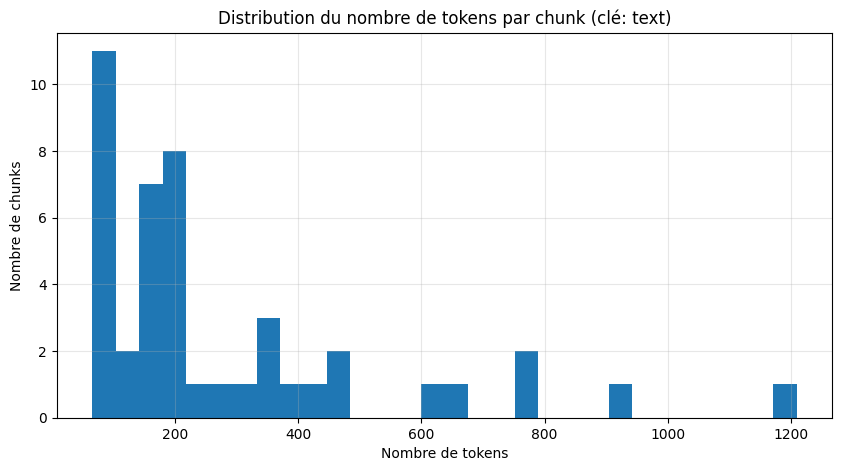

Nb chunks: 44
Min: 66 | Max: 1209
Moyenne: 280.6
Median: 193


In [17]:
import matplotlib.pyplot as plt

# 1) Récupère les textes
texts = [c.text for c in chunks if getattr(c, "text", None)]

# 2) Tokenizer
# pip install tiktoken
import tiktoken

# Choisis l'encodage adapté au modèle.
# - "o200k_base" marche bien pour les modèles récents
enc = tiktoken.get_encoding("o200k_base")

token_counts = [len(enc.encode(t)) for t in texts]

# 3) Histogramme
plt.figure(figsize=(10, 5))
plt.hist(token_counts, bins=30)
plt.title("Distribution du nombre de tokens par chunk (clé: text)")
plt.xlabel("Nombre de tokens")
plt.ylabel("Nombre de chunks")
plt.grid(True, alpha=0.3)
plt.show()

# 4) Stats utiles
print(f"Nb chunks: {len(token_counts)}")
print(f"Min: {min(token_counts)} | Max: {max(token_counts)}")
print(f"Moyenne: {sum(token_counts)/len(token_counts):.1f}")
print(f"Median: {sorted(token_counts)[len(token_counts)//2]}")


In [18]:
import json
from dataclasses import asdict, is_dataclass

def chunk_to_dict(c):
    # 1) dataclass
    if is_dataclass(c):
        return asdict(c)

    # 2) pydantic v2
    if hasattr(c, "model_dump"):
        return c.model_dump()

    # 3) pydantic v1
    if hasattr(c, "dict"):
        return c.dict()

    # 4) objet Python classique
    if hasattr(c, "__dict__"):
        return dict(c.__dict__)

    # 5) dernier recours
    return {"repr": repr(c)}

chunks_dicts = [chunk_to_dict(c) for c in chunks]  # chunks = ta liste de Chunk(...)
with open("chunks_2.json", "w", encoding="utf-8") as f:
    json.dump(chunks_dicts, f, ensure_ascii=False, indent=2)

print("✅ écrit dans chunks.json")



✅ écrit dans chunks.json


## 2.2 Chunks ppt

In [ ]:
from __future__ import annotations
import re
import logging
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

# =========================
# Configuration
# =========================
@dataclass
class ChunkingConfig:
    chunk_size_tokens: int = 1000
    chunk_overlap_tokens: int = 100
    chars_per_token: int = 4
    
    # Comportement
    drop_bibliography: bool = True
    drop_appendix: bool = True
    stop_after_appendix_start: bool = True 
    min_chunk_chars: int = 100 # PPT a parfois peu de texte par slide
    
    # Marqueurs
    appendix_markers: Tuple[str, ...] = ("annexe", "annexes", "appendix", "appendice", "conclusion")
    bibliography_markers: Tuple[str, ...] = ("bibliographie", "references", "sources")

# =========================
# Modèle Chunk
# =========================
@dataclass
class Chunk:
    id: str
    source: str
    section_title: str
    text: str
    page_no: int
    meta: Dict[str, Any]

# =========================
# Fonctions Utilitaires
# =========================
def _count_tokens(text: str, cfg: ChunkingConfig) -> int:
    try:
        import tiktoken
        enc = tiktoken.get_encoding("cl100k_base")
        return len(enc.encode(text))
    except:
        return len(text) // cfg.chars_per_token

def _is_marker_present(title: str, markers: Tuple[str, ...]) -> bool:
    t = title.lower().strip()
    t_clean = re.sub(r'^[\d\.]+\s+', '', t)
    for m in markers:
        if rf"\b{re.escape(m)}\b" in t_clean and len(t_clean.split()) <= 2:
            return True
    return False

# =========================
# Logique de Chunking PPTX
# =========================
# def chunk_pptx_from_res(res: Any, cfg: Optional[ChunkingConfig] = None) -> List[Chunk]:
#     cfg = cfg or ChunkingConfig()
    
#     # Récupération du markdown brut
#     md_raw = res.artifacts.get("markdown_final") or res.artifacts.get("markdown") or ""
#     source = getattr(res, "source", "unknown_pptx")
    
#     # 1. Découpage par Page (Slide)
#     # On utilise le placeholder généré par Docling
#     slides = md_raw.split("<!-- page_break -->")
    
#     chunks: List[Chunk] = []
#     in_excluded_zone = False

#     for i, slide_content in enumerate(slides):
#         page_no = i + 1
#         slide_content = slide_content.strip()
#         if not slide_content:
#             continue

#         # 2. Identification du titre de la slide
#         # Souvent la première ligne ou le premier # 
#         lines = slide_content.split('\n')
#         slide_title = "Sans titre"
#         for line in lines:
#             clean_line = line.strip().lstrip('#').strip()
#             if clean_line:
#                 slide_title = clean_line
#                 break

#         # 3. Filtrage Appendice / Fin de doc
#         if _is_marker_present(slide_title, cfg.appendix_markers) or \
#            _is_marker_present(slide_title, cfg.bibliography_markers):
#             in_excluded_zone = True
            
#         if in_excluded_zone and cfg.stop_after_appendix_start:
#             continue

#         # 4. Nettoyage et préparation
#         # On garde l'intégralité de la slide dans la meta pour le RAG
#         full_slide_text = slide_content.replace("<!-- image_placeholder -->", "[Image]").strip()

#         # 5. Chunking de la slide
#         # Si la slide est très courte, on fait un seul chunk.
#         # Si elle est très longue (rare en PPT), on pourrait la diviser, 
#         # mais ici on privilégie l'unité de la slide.
        
#         tokens = _count_tokens(full_slide_text, cfg)
        
#         # Création du chunk
#         meta = {
#             "type": "pptx_slide",
#             "tokens_est": tokens,
#             "full_page_text": full_slide_text, # Référence totale pour l'IA
#             "slide_title": slide_title
#         }

#         chunks.append(Chunk(
#             id=f"{source}::slide_{page_no:03d}",
#             source=source,
#             section_title=slide_title,
#             text=full_slide_text,
#             page_no=page_no,
#             meta=meta
#         ))

#     return [c for c in chunks if len(c.text) >= cfg.min_chunk_chars]

# =========================
# Logique de Chunking PPTX Corrigée
# =========================
def chunk_pptx_from_res(res: Any, cfg: Optional[ChunkingConfig] = None) -> List[Chunk]:
    cfg = cfg or ChunkingConfig()
    
    # Récupération du markdown brut
    md_raw = res.artifacts.get("markdown_final") or res.artifacts.get("markdown") or ""
    source = getattr(res, "source", "unknown_pptx")
    
    # 1. Découpage par Page (Slide)
    raw_slides = md_raw.split("<!-- page_break -->")
    
    # --- CORRECTION DU DÉCALAGE ---
    # On nettoie et on ne garde que les segments qui contiennent du vrai texte
    # Cela évite que le split crée une "Page 1" vide si le doc commence par un saut de page.
    slides = [s.strip() for s in raw_slides if s.strip()]
    
    chunks: List[Chunk] = []
    in_excluded_zone = False

    for i, slide_content in enumerate(slides):
        # Maintenant, l'index 0 est forcément la première slide réelle.
        page_no = i + 1
        
        # 2. Identification du titre de la slide
        lines = slide_content.split('\n')
        slide_title = "Sans titre"
        for line in lines:
            clean_line = line.strip().lstrip('#').strip()
            if clean_line:
                slide_title = clean_line
                break

        # 3. Filtrage Appendice / Fin de doc
        if _is_marker_present(slide_title, cfg.appendix_markers) or \
           _is_marker_present(slide_title, cfg.bibliography_markers):
            in_excluded_zone = True
            
        if in_excluded_zone and cfg.stop_after_appendix_start:
            continue

        # 4. Nettoyage (Placeholder image -> Tag texte)
        full_slide_text = slide_content.replace("<!-- image_placeholder -->", "[Image]").strip()

        # 5. Calcul des tokens
        tokens = _count_tokens(full_slide_text, cfg)
        
        # 6. Création du chunk
        # On inclut le texte complet de la slide en meta pour la référence RAG
        meta = {
            "type": "pptx_slide",
            "tokens_est": tokens,
            "full_page_text": full_slide_text, 
            "slide_title": slide_title
        }

        chunks.append(Chunk(
            id=f"{source}::slide_{page_no:03d}",
            source=source,
            section_title=slide_title,
            text=full_slide_text,
            #page_no=page_no,
            meta=meta
        ))

    return [c for c in chunks if len(c.text) >= cfg.min_chunk_chars]

# =========================
# Exemple d'Usage
# =========================
# factory = UniversalExtractorFactory(config=ExtractConfig())
# res = factory.extract("votre_presentation.pptx")
# chunks = chunk_pptx_from_res(res)

In [ ]:
chunks = chunk_pptx_from_res(res)